<a href="https://colab.research.google.com/github/jrapakko/cse11b/blob/main/Spotify_Genre_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting song genre from audio features

This dataset has about 32,000 Spotify songs. Each one has a genre and a set of audio features Spotify computes from the sound, like danceability and energy.

We'll explore and clean the data, then train a model to predict genre from the audio features alone.

## Load the data

`read_csv` accepts a URL as well as a file path.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

In [ ]:
df.shape

(32833, 23)

In [ ]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## Column types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

The name, artist and album columns have 5 fewer non-null values than the rest.

`track_album_release_date` is stored as text.

## Missing values

In [ ]:
df.isna().sum()

,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


In [ ]:
df[df["track_name"].isna()]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
8151,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707
9282,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,11,-5.364,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235
9283,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,10,-5.907,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465
19568,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,...,11,-6.075,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773
19811,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707


5 rows out of 32,833 with no name, artist or album so we'll drop them.

In [ ]:
df = df.dropna()
df.shape

(32828, 23)

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

No exact duplicates. But this data was collected from playlists, so a song that appears in several playlists gets a row for each one. Those rows differ in the playlist columns, so `duplicated()` doesn't count them.

`track_id` is unique per song, so we'll use that to count instead.

In [ ]:
df.duplicated(subset="track_id").sum()

np.int64(4476)

Example: Blinding Lights by The Weeknd

In [ ]:
blinding = df[df["track_id"] == "0sf12qNH5qcw8qpgymFOqD"]
blinding[["track_name", "track_artist", "playlist_name", "playlist_genre", "danceability", "energy"]]

,track_name,track_artist,playlist_name,playlist_genre,danceability,energy
716,Blinding Lights,The Weeknd,Todo Éxitos,pop,0.513,0.796
1605,Blinding Lights,The Weeknd,"post-teen alternative, indie, pop (large variety)",pop,0.513,0.796
4713,Blinding Lights,The Weeknd,indie poptimism🕺🏻,pop,0.513,0.796
18307,Blinding Lights,The Weeknd,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,latin,0.513,0.796
19715,Blinding Lights,The Weeknd,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,latin,0.513,0.796
21571,Blinding Lights,The Weeknd,Most Popular 2020 TOP 50,r&b,0.513,0.796
22933,Blinding Lights,The Weeknd,Pop Hits 2020,r&b,0.513,0.796
30203,Blinding Lights,The Weeknd,Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Po...,edm,0.513,0.796


8 rows for the same song with identical audio features but different genres?

A model can't learn if the data is inconsistent, so we keep one row per song.

In [ ]:
df = df.drop_duplicates(subset="track_id")
df.shape

(28352, 23)

This keeps the first row, but is the genre right?

What does this mean for our predictions?

## Release year

The release date column is text.

In [ ]:
df["track_album_release_date"].sample(10, random_state=1)

,track_album_release_date
8828,2015-07-24
5274,2017-04-20
24468,2007-01-01
1686,2006-08-22
7662,1988-01-01
4549,2016-09-23
25616,2016-02-29
16000,2014-02-21
5284,2017-03-24
10860,2020-01-09


In [ ]:
df["track_album_release_date"].str.len().value_counts()

,count
track_album_release_date,
10,26671
4,1656
7,25


Three formats: `2019-06-14`, `2012`, `1981-12`

All of them start with the year, so try taking the first 4 characters and convert to int.

In [ ]:
df["year"] = df["track_album_release_date"].str[:4].astype(int)
df["year"].describe()

,year
count,28352.000000
mean,2011.053541
std,11.229899
min,1957.000000
25%,2008.000000
50%,2016.000000
75%,2019.000000
max,2020.000000


## Duration in minutes

In [ ]:
df["minutes"] = df["duration_ms"] / 60000
df["minutes"].describe()

,minutes
count,28352.000000
mean,3.776244
std,1.018023
min,0.066667
25%,3.129021
50%,3.615550
75%,4.249588
max,8.630167


## Checking ranges

In [ ]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,minutes
count,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000
mean,39.335320,0.653375,0.698373,5.367417,-6.817777,0.565533,0.107939,0.177192,0.091129,0.190955,0.510386,120.958219,226574.631102,2011.053541,3.776244
std,23.699443,0.145791,0.183508,3.613743,3.036433,0.495696,0.102547,0.222814,0.232562,0.155888,0.234344,26.954502,61081.363704,11.229899,1.018023
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,1957.000000,0.066667
25%,21.000000,0.561000,0.579000,2.000000,-8.310250,0.000000,0.041000,0.014300,0.000000,0.092600,0.329000,99.972000,187741.250000,2008.000000,3.129021
50%,42.000000,0.670000,0.722000,6.000000,-6.261000,1.000000,0.062600,0.079700,0.000021,0.127000,0.512000,121.993500,216933.000000,2016.000000,3.615550
75%,58.000000,0.760000,0.843000,9.000000,-4.708750,1.000000,0.133000,0.260000,0.006573,0.249000,0.695000,133.999000,254975.250000,2019.000000,4.249588
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,2020.000000,8.630167


The shortest track is about 4 seconds and the lowest tempo is 0.

Let's look for tracks under a minute.

In [ ]:
df[df["minutes"] < 1][["track_name", "track_artist", "minutes", "playlist_genre"]]

,track_name,track_artist,minutes,playlist_genre
1516,Canción del encantamiento,Carmen López,0.907550,pop
2253,raindrops (an angel cried),Ariana Grande,0.627333,pop
5653,Smile Again,Green Assassin Dollar,0.963850,rap
5679,Spanish Galleon,Wun Two,0.910933,rap
5726,blxt,asbeluxt,0.934033,rap
5738,night time,Chill Children,0.993333,rap
8325,It Was All a Dream,DJ Screw & The Screwed Up Click,0.767550,rap
8331,I'm Going to Live My Life,DJ Screw & The Screwed Up Click,0.766667,rap
8339,The Screwed Up Click,DJ Screw & The Screwed Up Click,0.491550,rap
11363,"Hi, How're You Doin'?",DREAMS COME TRUE,0.066667,rock


Mostly intros, skits and interludes. They aren't representative of their genre, so drop them.

Then check the tempo 0 track.

In [ ]:
df = df[df["minutes"] >= 1]
df[df["tempo"] == 0]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,minutes


It was one of the short tracks, so it's already gone.

In [ ]:
df.shape

(28327, 25)

## Exploring genres

In [ ]:
df["playlist_genre"].value_counts()

,count
playlist_genre,
rap,5391
pop,5130
edm,4868
r&b,4502
rock,4302
latin,4134


The classes are reasonably balanced, so the model can't score well by always guessing one genre.

Remember how we talked about this last week (with network data)? Imbalanced datasets can cause issues, so always consider the consequences.

`groupby` splits the rows by genre and `.mean()` averages each column within each group.

In [ ]:
df.groupby("playlist_genre")[["danceability", "energy", "speechiness", "acousticness", "valence"]].mean()

,danceability,energy,speechiness,acousticness,valence
playlist_genre,,,,,
edm,0.657658,0.809740,0.087886,0.076498,0.397306
latin,0.711079,0.710635,0.100373,0.212580,0.607477
pop,0.637808,0.701257,0.074173,0.171808,0.502188
r&b,0.667560,0.589068,0.115532,0.264005,0.538041
rap,0.716204,0.649966,0.197302,0.195668,0.504946
rock,0.518702,0.733067,0.057954,0.147576,0.532707


Rap has much higher speechiness than anything else. Rock has the lowest danceability, EDM the highest energy, and latin the highest valence.

The model will learn from these differences.

## Plots

<Axes: >

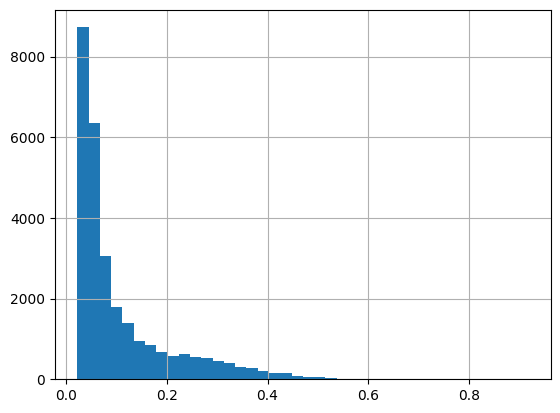

In [ ]:
df["speechiness"].hist(bins=40)

Most songs have low speechiness, with a long tail.

A box plot splits one column by group. The box covers the middle 50% of values, the line is the median, and the dots are outliers.

<Axes: title={'center': 'speechiness'}, xlabel='playlist_genre'>

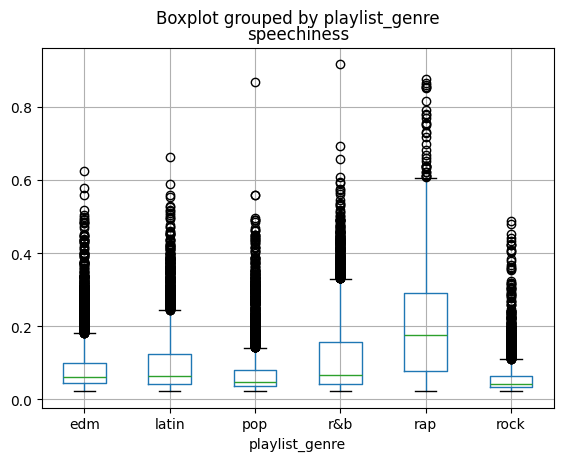

In [ ]:
df.boxplot(column="speechiness", by="playlist_genre")

Songs per release year:

<Axes: xlabel='year'>

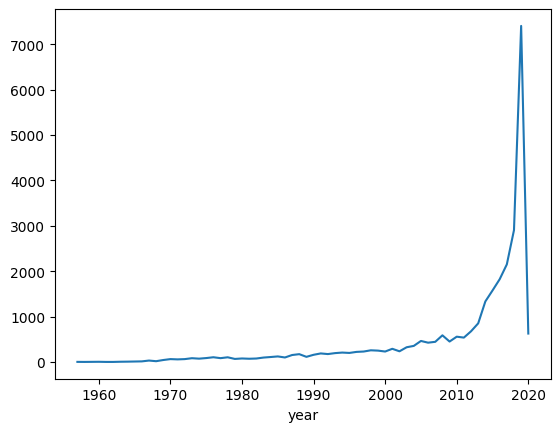

In [ ]:
df["year"].value_counts().sort_index().plot()

The data is heavily skewed toward recent music, so the model will know much less about older songs.

Energy vs loudness. `alpha` makes the dots transparent so dense areas show up darker.

<Axes: xlabel='loudness', ylabel='energy'>

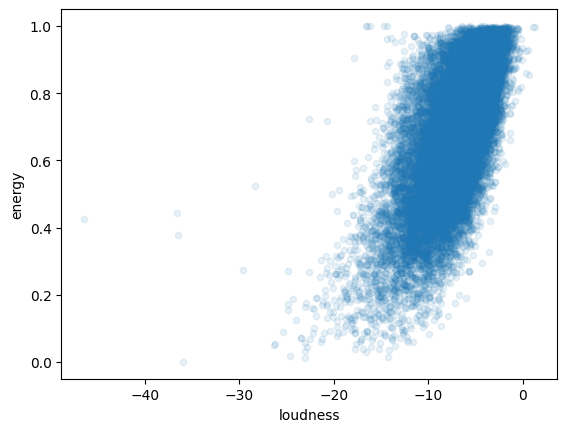

In [ ]:
df.plot.scatter(x="loudness", y="energy", alpha=0.1)

Louder songs tend to have more energy.

## Preparing features (Extra)

`X` holds the inputs and `y` holds the target. We only use audio features. IDs, names and playlist info either don't describe the sound or would give the answer away.

In [ ]:
features = ["danceability", "energy", "loudness", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "minutes"]

X = df[features]
y = df["playlist_genre"]

We hold out 20% of the songs for testing. The model never sees them during training, so the test score tells us how well it handles new songs.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state ensures same split is chosen between runs
len(X_train), len(X_test)

(22661, 5666)

## Training (Extra)

A random forest is a collection of decision trees. Each tree learns a series of yes/no splits like "speechiness > 0.2", and the trees vote on the final prediction. We'll cover how they work later. For now, `fit` trains it.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

`score` returns the fraction of test songs it got right.

In [ ]:
model.score(X_test, y_test)

0.5691846099541122

About 57%.
With 6 genres, random guessing gets about 17%, so the model is learning.

Overlapping genres and inconsistent labels (like Blinding Lights) keep it from going much higher.

Any other ideas on what we can do on the data side?